In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("train.csv")
print(df.head())
print(df.info())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [6]:
# for missing values

print(df.isnull().sum())

# if null values then df['row_name'] = df['row_name'].fillna(0)
# if drop duplicates df = df.drop_duplicates()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


In [9]:
# For Date time 
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Ship weekday'] = df['Ship Date'].dt.day_name()

In [10]:
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

df['Region_Category'] = df['Region'] + " - " + df['Category']

In [11]:
sale_by_region_year = df.groupby(['Region', 'Order Year'])['Sales'].sum().reset_index()

pivot = df.pivot_table(index= 'State', columns= 'Category', values= 'Sales', aggfunc= 'sum')
print(pivot)

Category                Furniture  Office Supplies  Technology
State                                                         
Alabama                 6332.4800         4209.080    8969.080
Arizona                13525.2910         9996.481   11750.885
Arkansas                3187.5500         4565.330    3925.250
California            152216.5355       139405.748  154684.180
Colorado               13220.2850         7654.984   10966.329
Connecticut             5174.9870         5418.340    2791.030
Delaware                4745.9190         8014.860   14562.220
District of Columbia    1346.5800          138.520    1379.920
Florida                22743.0140        18725.482   46968.036
Georgia                 8321.4800        26397.780   13499.850
Idaho                   2595.4820          949.506     837.498
Illinois               28212.9780        19385.658   31637.881
Indiana                 9551.8700        13206.860   25959.670
Iowa                    2627.4000          661.860    1

In [15]:
df['Cumulative Sales'] = df.groupby('Customer ID')['Sales'].cumsum()

sales_by_year = df.groupby('Order Year')['Sales'].sum().reset_index()
sales_by_year['Prev_Sales'] = sales_by_year['Sales'].shift(1)
sales_by_year['YOY Growth %'] = np.where(
    sales_by_year['Prev_Sales'] > 0,
    ((sales_by_year['Sales'] - sales_by_year['Prev_Sales']) / sales_by_year['Prev_Sales']) *100,
    np.nan
)

In [16]:
df.to_csv("sales_cleaned.csv", index = False)

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style = "whitegrid")

C:\Users\PANKAJ\AppData\Local\Temp\ipykernel_15880\97639861.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = region_sales, x = 'Region', y = 'Sales', palette = 'viridis')


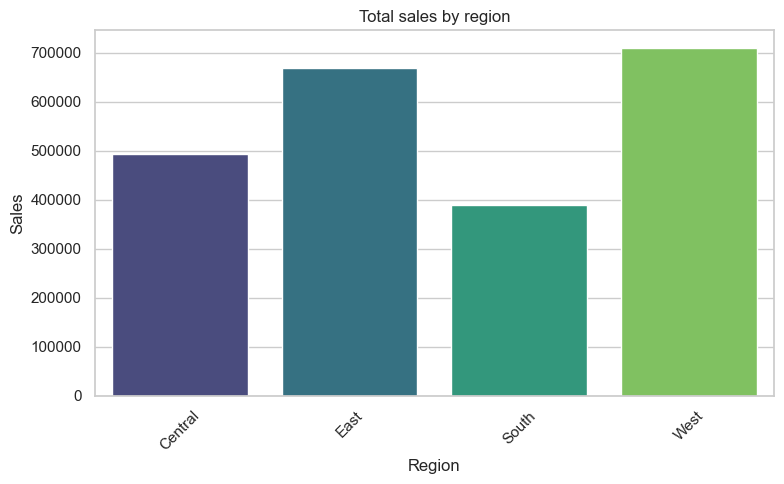

In [25]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data = region_sales, x = 'Region', y = 'Sales', palette = 'viridis')
plt.title('Total sales by region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig('Region_sales.png')
plt.show()

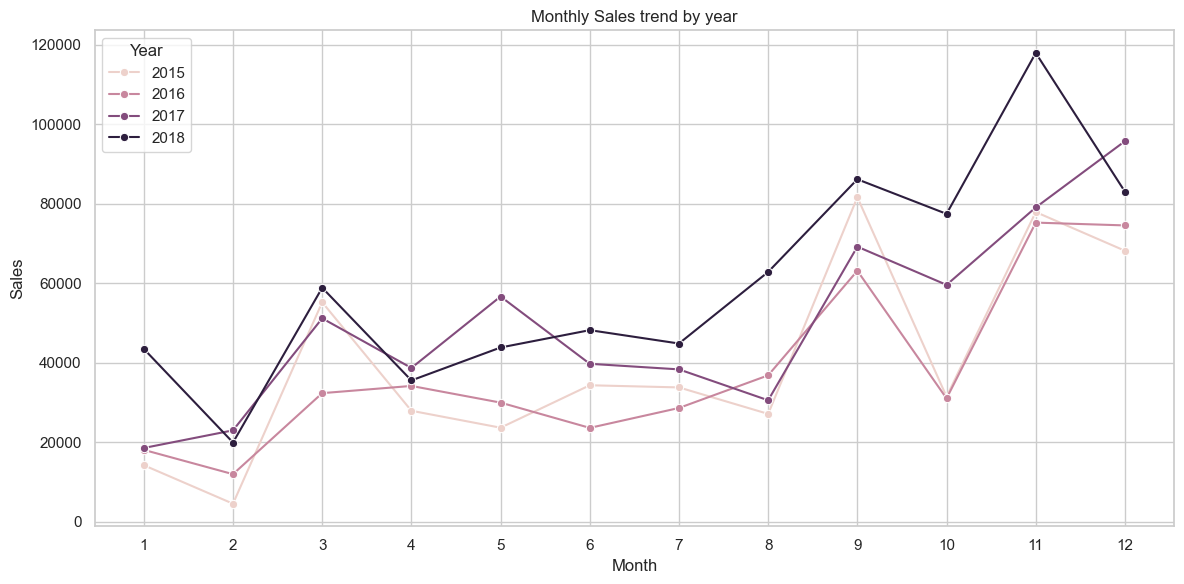

In [26]:
# Monthy Sales trend

monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()

plt.figure(figsize = (12, 6))
sns.lineplot(data = monthly_sales, x = 'Order Month', y = 'Sales', hue = 'Order Year', marker='o')
plt.title('Monthly Sales trend by year')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(range(1, 13))
plt.legend(title = 'Year')
plt.tight_layout()
plt.savefig('monthly_sales.png')
plt.show()

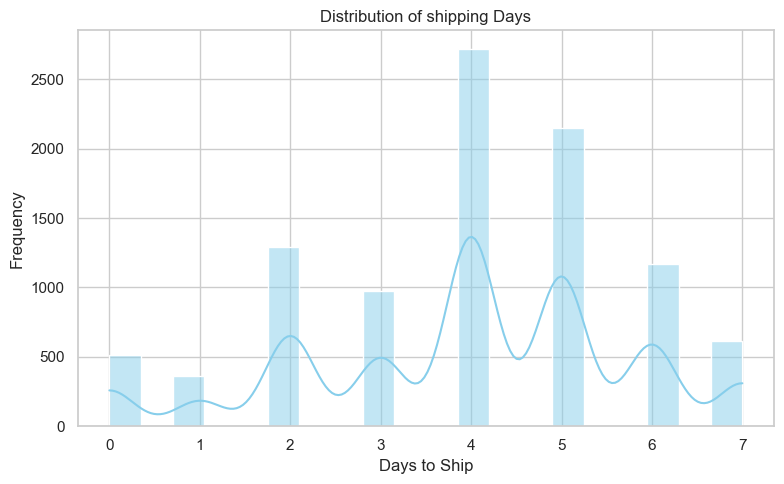

In [27]:
# shipping days distribution

plt.figure(figsize = (8, 5))
sns.histplot(df['Shipping Days'], bins = 20, kde = True, color = 'skyblue')
plt.title('Distribution of shipping Days')
plt.xlabel('Days to Ship')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Distribution_of_shipping_Days.png')
plt.show()